## Strategy Backtest III

- Same procedure as **Strategy Backtest I**
- Uses a date well separated from Backtests I & II to test the model in a different market regime

Results reported using NVDA MBP data on 2026-07-17.

### Raw Data Loading

Load raw MBP-10 ticks, trim the opening/closing minutes, and truncate to `data_depth` book levels. Then split off a holdout period (`data_holdout`) which is reserved for out-of-sample validation of any hyperparameters tuned on `data_train`.

In [14]:
### Data Loading
from execution_timing.data_loading import read_raw_data, truncate_depth, holdout_split
from execution_timing.config import FACTOR_HYPERPARAMETERS_DIRECTION, LABEL_HYPERPARAMETERS
from execution_timing.feature_engineering import load_factors_and_labels
from execution_timing.rolling_window_generator import RollingWindowGenerator, Window

data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-17.parquet', trim_open_and_close=True)
data_depth = 3
data = truncate_depth(data_mbp10, data_depth)
data_train, data_holdout = holdout_split(data, holdout_mins=120, purge_ticks=0)
print(f"Train data shape: {data_train.shape}")
print(f"Holdout data shape: {data_holdout.shape}")

Train data shape: (3244494, 12)
Holdout data shape: (1118203, 12)


### Feature Engineering

Build the direction factors (`FACTOR_HYPERPARAMETERS_DIRECTION`) and the `ask_return_direction` label on `data_train`, and split into rolling train/test windows (`RollingWindowGenerator`) for walk-forward backtesting.

In [15]:
factors, labels = load_factors_and_labels(
    data=data_train,
    data_depth=data_depth,
    factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
    label_hyperparameters=LABEL_HYPERPARAMETERS,
    dropna=True)

X = factors
y = labels['ask_return_direction']
rolling_window_generator = RollingWindowGenerator(X=X,
                                                  y=y,
                                                  train_window_size_mins=25,
                                                  test_window_size_mins=5,
                                                  step_size_mins=5,
                                                  purge_secs=1)
windows = list(iter(rolling_window_generator))
print(f"Windows count: {len(windows)}")
print(f"Windows start time: {windows[0].train_start}")
print(f"Windows end time: {windows[-1].test_end}")

Dropped 600 rows with NaN values
Windows count: 37
Windows start time: 2026-07-17 10:00:00-04:00
Windows end time: 2026-07-17 13:30:00-04:00


### Run Trading Simulation

- `PredictionModel` -- wraps `LogisticRegression` which is used to predict future price direction
- `StrategyDirection` -- converts model prediction into 0/1 trading signal
- `TradingSimulator` -- turns trading signal into fills against raw ask/bid ticks.

`run_simulation` walks forward window by window, retraining, predicting, generating the signal, and simulating fills, returning the per-minute trade results (`trading_result`) and each window's fitted factor coefficients (`model_coeff`).

In [16]:
from execution_timing.prediction_model import PredictionModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from execution_timing.trading_strategy import StrategyDirection
from execution_timing.trading_simulator import TradingSimulator, run_simulation


dir_model = PredictionModel(
    model=LogisticRegression(l1_ratio=0, # penalty = l1_ratio * L1 + (1 − l1_ratio) * L2; l1_ratio=0 -> Ridge
                           C=0.01, # C=1/alpha where alpha is the coefficient for penalty term; bigger alpha mode penalty
                           max_iter=10000,),
    scaler=StandardScaler(),
)

strategy = StrategyDirection(dir_pred_model=dir_model,
                             dir_threshold=0.55,
                             sig_resample_freq=None)
trading_simulator = TradingSimulator(raw_price=data_train[['ask_px_00', 'bid_px_00']],
                             execution_lag_ticks=0)


In [17]:
trading_result, model_coeff = run_simulation(strategy=strategy,
                            trading_simulator=trading_simulator,
                            windows=windows)

In [18]:
display(trading_result)

,#window,execution_time,execution_second,fill_price,arrival_ask,departure_ask,mean_ask,max_ask,min_ask,arrival_bid,departure_bid,arrival_spread,departure_spread,pnl,pnl_pct_spread
2026-07-17 10:25:00-04:00,0,2026-07-17 10:25:00.837836019-04:00,0.837836,204.72,204.72,204.47,204.668150,204.98,204.41,204.68,204.44,0.04,0.03,0.00,0.000000
2026-07-17 10:26:00-04:00,0,2026-07-17 10:26:00.710861273-04:00,0.710861,204.32,204.47,204.30,204.386750,204.49,204.25,204.44,204.26,0.03,0.04,0.15,5.000000
2026-07-17 10:27:00-04:00,0,2026-07-17 10:27:01.751595029-04:00,1.751595,204.31,204.30,204.43,204.432561,204.63,204.21,204.26,204.40,0.04,0.03,-0.01,-0.250000
2026-07-17 10:28:00-04:00,0,2026-07-17 10:28:01.910764902-04:00,1.910765,204.44,204.43,204.00,204.080924,204.46,203.92,204.40,203.98,0.03,0.02,-0.01,-0.333333
2026-07-17 10:29:00-04:00,0,2026-07-17 10:29:00.246449274-04:00,0.246449,204.01,204.00,203.82,203.779080,204.01,203.63,203.97,203.79,0.03,0.03,-0.01,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-17 13:25:00-04:00,36,2026-07-17 13:25:06.600156136-04:00,6.600156,205.72,205.72,205.81,205.793815,205.84,205.69,205.69,205.80,0.03,0.01,0.00,0.000000
2026-07-17 13:26:00-04:00,36,2026-07-17 13:26:59.898275045-04:00,59.898275,206.01,205.81,206.01,205.948735,206.04,205.81,205.79,205.99,0.02,0.02,-0.20,-10.000000
2026-07-17 13:27:00-04:00,36,2026-07-17 13:27:04.248308698-04:00,4.248309,206.04,206.01,206.11,206.054717,206.14,205.97,205.99,206.09,0.02,0.02,-0.03,-1.500000
2026-07-17 13:28:00-04:00,36,2026-07-17 13:28:59.864267541-04:00,59.864268,206.05,206.11,206.05,206.112837,206.19,206.03,206.09,206.04,0.02,0.01,0.06,3.000000


In [19]:
display(model_coeff)

,window_0,window_1,window_2,window_3,window_4,window_5,window_6,window_7,window_8,window_9,...,window_27,window_28,window_29,window_30,window_31,window_32,window_33,window_34,window_35,window_36
obi_weighted,0.037249,0.046275,0.047947,0.061084,0.067187,0.076084,0.076179,0.088112,0.089827,0.082800,...,0.134516,0.145783,0.165948,0.192993,0.150844,0.146363,0.106910,0.092174,0.077447,0.077948
spread_deviation,-0.111059,-0.113635,-0.125170,-0.119073,-0.094410,-0.105178,-0.110274,-0.108157,-0.098138,-0.110026,...,-0.162828,-0.165147,-0.143592,-0.142330,-0.113489,-0.099374,-0.128140,-0.155479,-0.128270,-0.183014
ask_px_momentum,0.020574,0.021106,0.043479,0.036765,0.017314,0.026134,0.033051,0.027927,0.007955,0.011605,...,-0.006241,0.001053,-0.013386,-0.010466,-0.037078,-0.054943,-0.048877,-0.049161,-0.084263,-0.019284
bid_px_momentum,0.076931,0.078310,0.058886,0.066162,0.103967,0.103308,0.099635,0.104687,0.088875,0.067023,...,0.004915,0.010634,0.017799,0.049111,0.073275,0.092077,0.057440,0.040862,0.030725,-0.023356
vwap_mid_deviation_ask,-0.074373,-0.079592,-0.079373,-0.090613,-0.077858,-0.073600,-0.058211,-0.060440,-0.075719,-0.075817,...,-0.075012,-0.099474,-0.123805,-0.096444,-0.068915,-0.042500,-0.030560,-0.022280,-0.051719,-0.056966


### Trade Result Evaluation

Summary metrics (cumulative/mean pnl, win rate, Sharpe ratio, trigger rate) plus diagnostic plots.

In [20]:
from execution_timing.visualization import (plot_cumulative_pnl,
                                            plot_execution_second_distribution,
                                            plot_pnl_histogram,
                                            plot_price_path,
                                            plot_coefficient_distribution,
                                            plot_price_and_pnl)
from execution_timing.trading_simulator import summarize_results, baseline_comparison

stats = summarize_results(trading_result)
display(stats)

,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,0.97,0.448649,0.081273,0.005243,0.281081,0.962162,0.022595


In [21]:
baseline_stats = baseline_comparison(trading_result)
display(baseline_stats)

,mean_pnl_per_share
buy_immediately,0.000000
random_tick,-0.010675
always_wait,-0.007730
model_timed,0.005243
perfect_foresight,0.160919


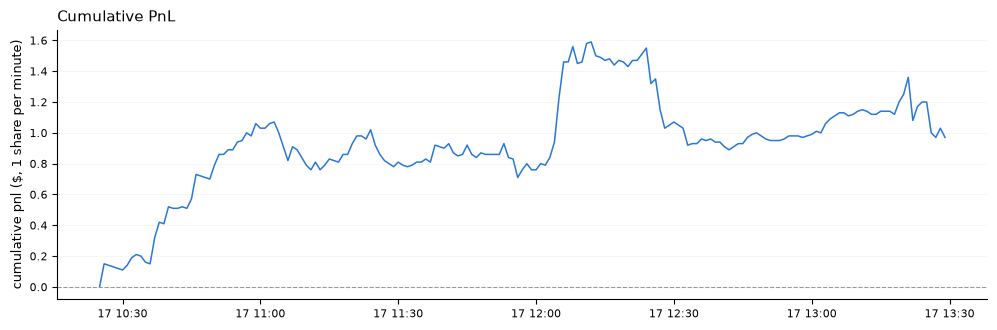

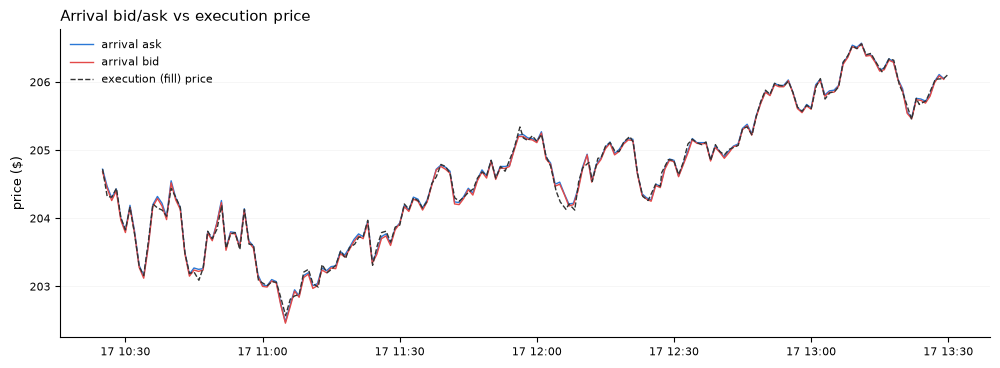

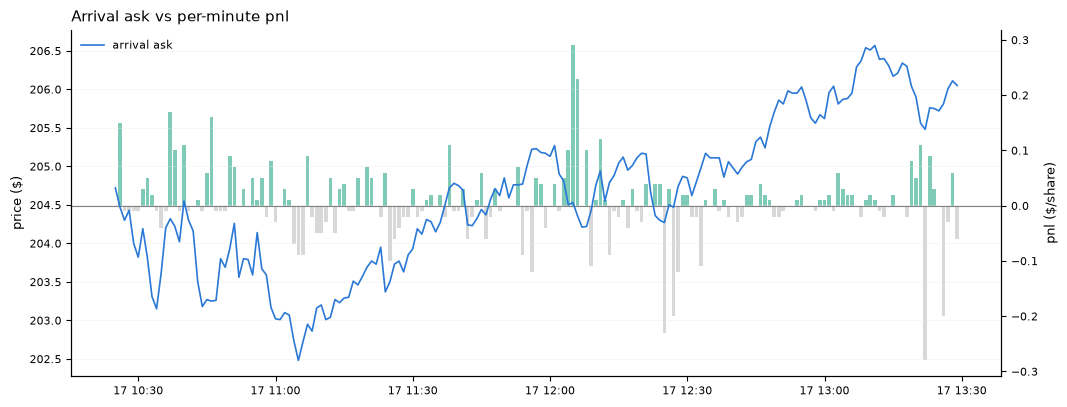

In [22]:
# cumulative pnl over the backtest
plot_cumulative_pnl(trading_result['pnl'].cumsum())

# arrival/departure bid-ask vs execution (fill) price, per minute
plot_price_path(trading_result)

# arrival ask overlaid with per-minute pnl on the same time axis
plot_price_and_pnl(trading_result)

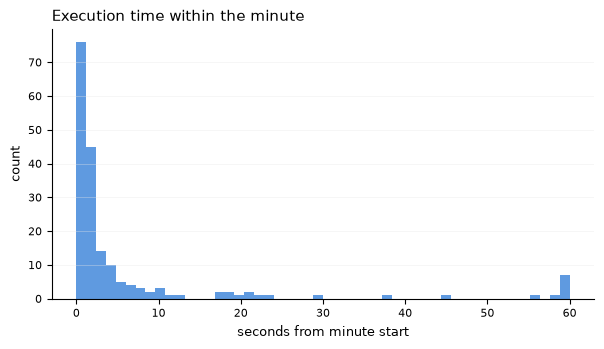

In [23]:
# when does execution happen in each minute
plot_execution_second_distribution(trading_result['execution_second'], bins=50)

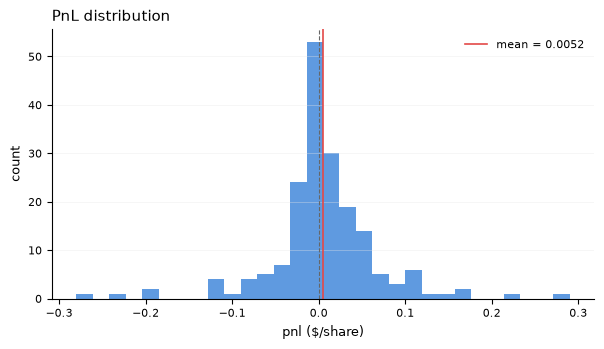

In [24]:
# per-minute pnl distribution
plot_pnl_histogram(trading_result['pnl'], bins=30)

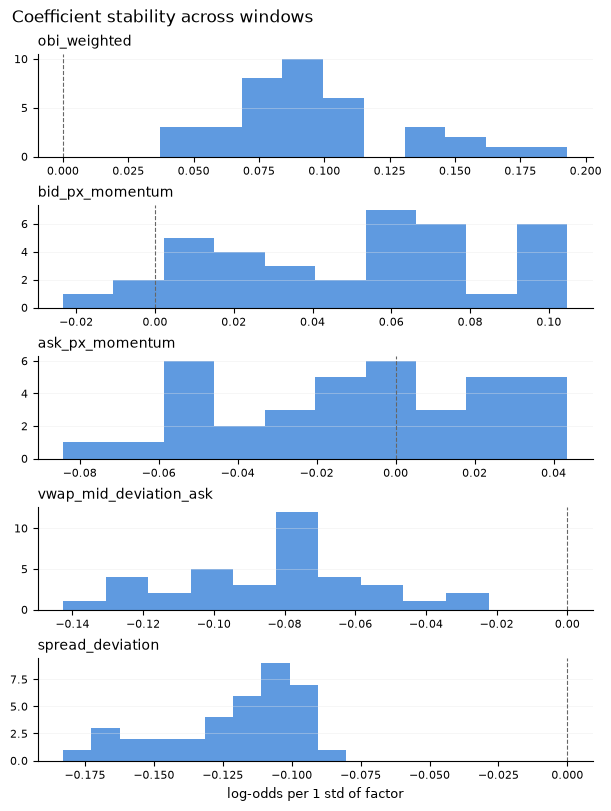

In [25]:
# per-factor coefficient stability across rolling windows; expect signs to be stable
plot_coefficient_distribution(model_coeff, bins=10)

### Holdout Evaluation
- True out-of-sample data which was never used before.
- Same pipeline (feature engineering -> rolling windows -> `run_simulation` -> `summarize_results` + plots) as above, run on `data_holdout` instead of `data_train`.

Dropped 600 rows with NaN values
Windows count: 19
Windows start time: 2026-07-17 13:30:00-04:00
Windows end time: 2026-07-17 15:30:00-04:00


,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,1.62,0.589474,0.128743,0.017053,0.887719,0.494737,0.019158


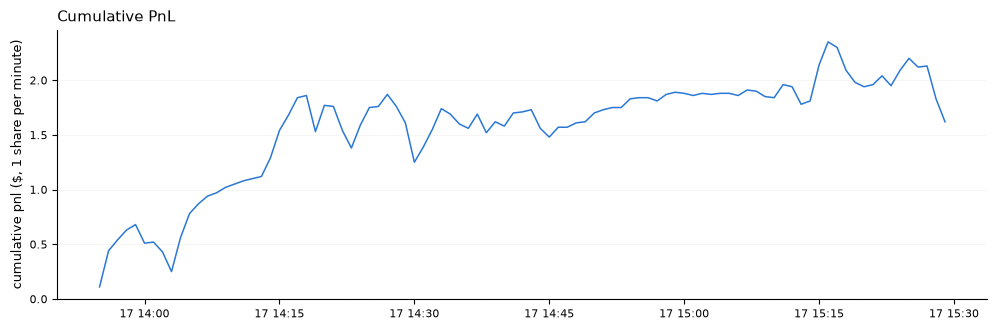

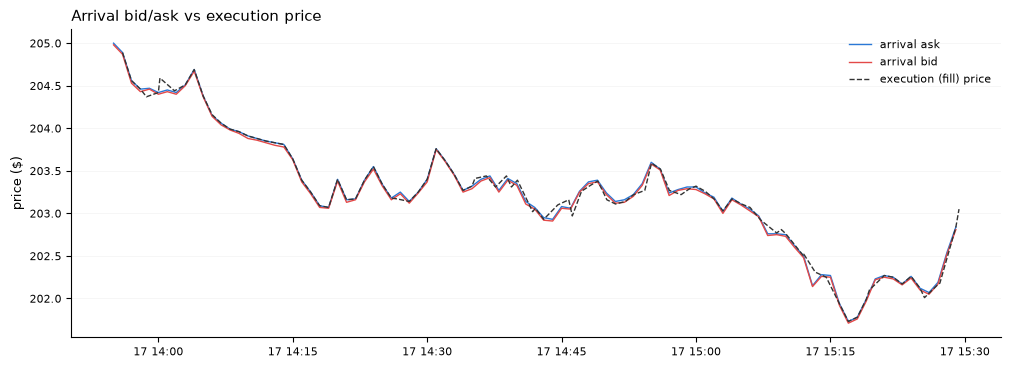

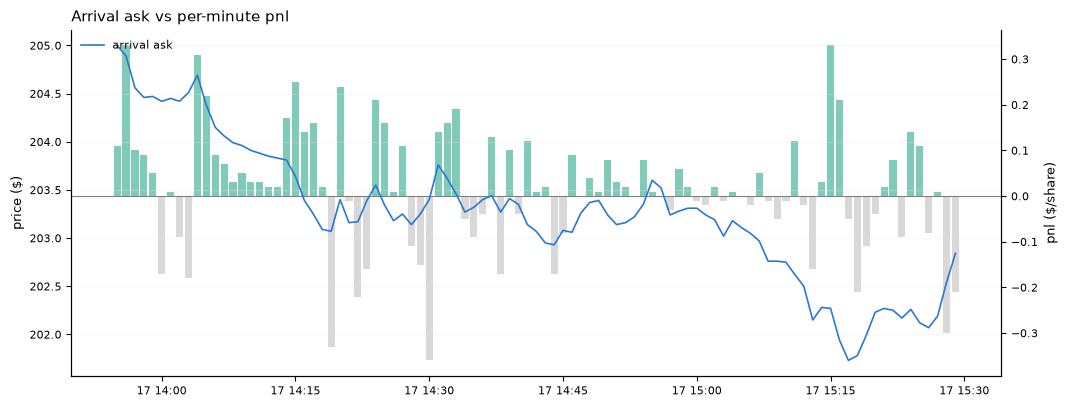

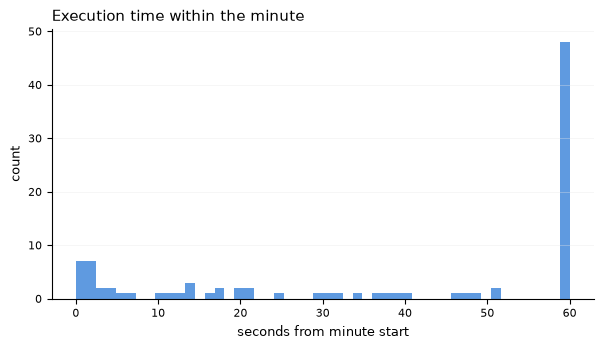

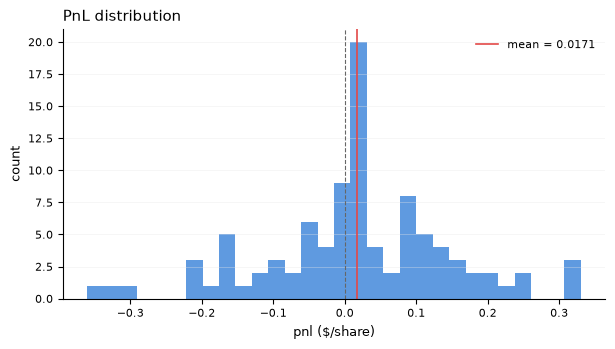

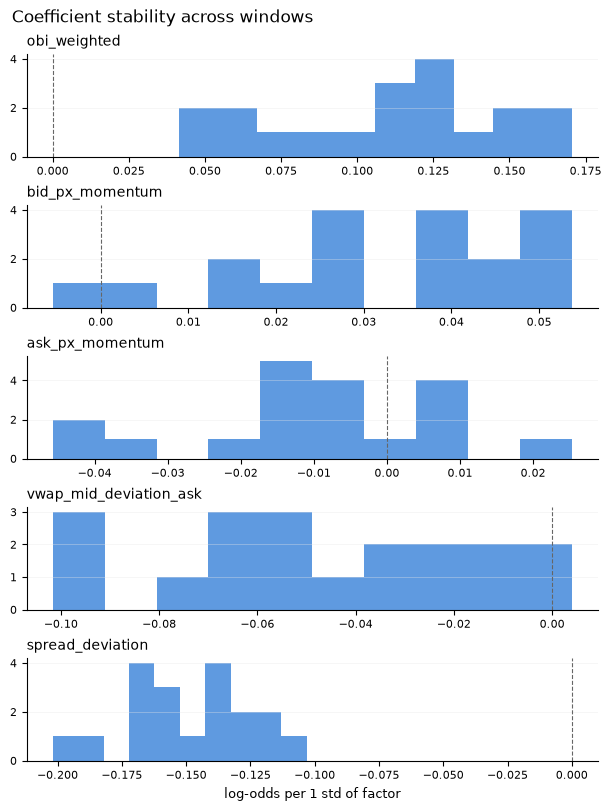

In [27]:
def backtest_and_evaluate(data,
                          data_depth=data_depth,
                          factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
                          label_hyperparameters=LABEL_HYPERPARAMETERS,
                          train_window_size_mins=25,
                          test_window_size_mins=5,
                          step_size_mins=5,
                          purge_secs=1,
                          dir_threshold=0.55,
                          sig_resample_freq=None,
                          execution_lag_ticks=0,
                          ):
    """
    Same steps as the sections above, parameterized by `data` so the whole
    pipeline can be re-run on a different split (e.g. data_holdout) without
    duplicating the cells.
    """
    factors, labels = load_factors_and_labels(
        data=data,
        data_depth=data_depth,
        factor_hyperparameters=factor_hyperparameters,
        label_hyperparameters=label_hyperparameters,
        dropna=True)

    X = factors
    y = labels['ask_return_direction']
    rolling_window_generator = RollingWindowGenerator(X=X,
                                                      y=y,
                                                      train_window_size_mins=train_window_size_mins,
                                                      test_window_size_mins=test_window_size_mins,
                                                      step_size_mins=step_size_mins,
                                                      purge_secs=purge_secs)
    windows = list(iter(rolling_window_generator))
    print(f"Windows count: {len(windows)}")
    if windows:
        print(f"Windows start time: {windows[0].train_start}")
        print(f"Windows end time: {windows[-1].test_end}")

    dir_model = PredictionModel(
        model=LogisticRegression(l1_ratio=0, C=0.01, max_iter=10000),
        scaler=StandardScaler(),
    )
    strategy = StrategyDirection(dir_pred_model=dir_model,
                                 dir_threshold=dir_threshold,
                                 sig_resample_freq=sig_resample_freq)
    trading_simulator = TradingSimulator(raw_price=data[['ask_px_00', 'bid_px_00']],
                                         execution_lag_ticks=execution_lag_ticks)

    trading_result, model_coeff = run_simulation(strategy=strategy,
                                                 trading_simulator=trading_simulator,
                                                 windows=windows)

    stats = summarize_results(trading_result)
    display(stats)

    plot_cumulative_pnl(trading_result['pnl'].cumsum())
    plot_price_path(trading_result)
    plot_price_and_pnl(trading_result)
    plot_execution_second_distribution(trading_result['execution_second'], bins=50)
    plot_pnl_histogram(trading_result['pnl'], bins=30)
    plot_coefficient_distribution(model_coeff, bins=10)

    return trading_result, model_coeff, stats
trading_result_holdout, model_coeff_holdout, stats_holdout = backtest_and_evaluate(data_holdout)